In [19]:
import sympy as sp
from math import factorial
import pandas as pd
x = sp.symbols('x')

def taylor_serie(f,x0,n):
    polinomio = 0
    for i in range(n+1):
        df = sp.diff(f,x,i)
        df_eval = sp.lambdify(x,df)
        polinomio += (df_eval(x0)/factorial(i))*(x-x0)**i
        
    return sp.expand(polinomio)        
        
        
def evaluacion(values,f,P):
    lista = []
    for i in values:
        lista.append([i, f(i), P(i), abs(f(i)-P(i)), abs((f(i)-P(i))/f(i))])
    lista = pd.DataFrame(data=lista, columns=["values_x", "f(x)", "P(x)", "|f(x) - P(x)|", "|f(x) - P(x)|/|f(x)|"])
    return lista        

In [20]:
import sympy as sp
import numpy as np

x = sp.symbols('x')
def cota_truncamiento(f, n, x0, x_point):
    df = sp.diff(f, x, n+1)
    df_eval = sp.lambdify(x,df)
    x_array = np.linspace(min(x0,x_point), max(x0,x_point),200)
    maximo = max(abs(df_eval(x_array)))
    cota= maximo * (abs(x0-x_point)** (n +1) / factorial(n+1))
    return cota

## Ejemplo Taylor:

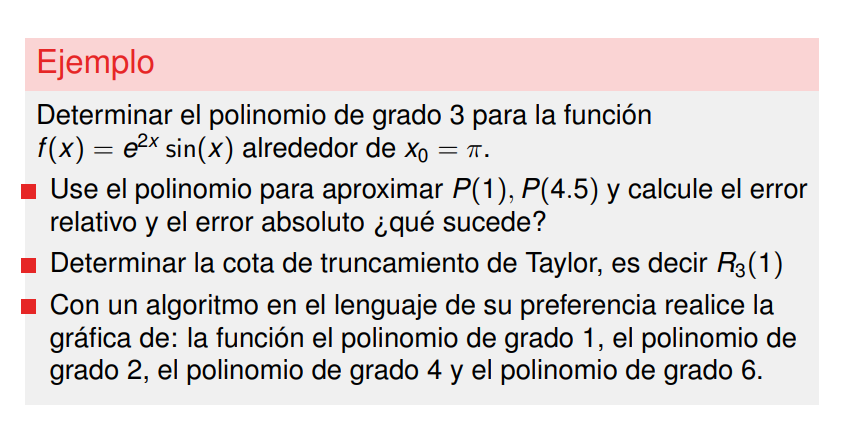

sympy: libreria para crear la funcion, simbolos


In [ ]:
import sympy as sp
import numpy as np

x = sp.symbols('x')
f = sp.exp(2*x)*sp.sin(x)
n=3
x0=np.pi
P_3= taylor_serie(f,x0,n)

f_eval = sp.lambdify(x,f)
P_eval= sp.lambdify(x, P_3)

print(evaluacion([1, 4.5], f_eval, P_eval))

cota_truncamiento(f, n, x0, 1)




   values_x         f(x)         P(x)  |f(x) - P(x)|  |f(x) - P(x)|/|f(x)|
0       1.0     6.217676  5877.661957    5871.444281            944.314883
1       4.5 -7921.008585 -5164.514431    2756.494154              0.347998


np.float64(11264.195548176733)

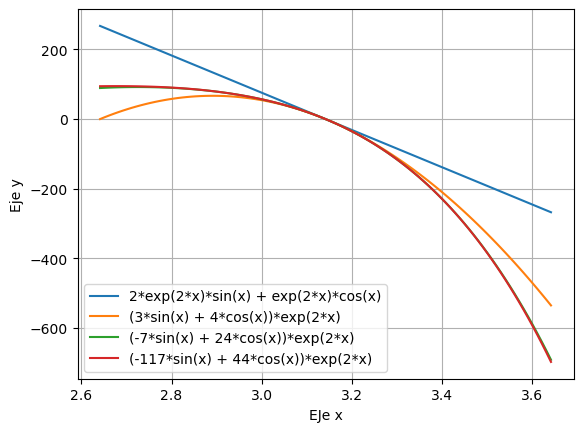

In [31]:
import matplotlib.pyplot as pl
grados = [1,2,4,6]
x0 = np.pi
def graficas_polinomio(f,x0,grados):
    delta = 0.5
    ux = np.linspace(x0-delta,x0+delta,100)
    for i in grados:
        P_x = taylor_serie(f,x0,i)
        P_eval = sp.lambdify(x,P_x)(ux)
        pl.plot(ux,P_eval, label=str(sp.diff(f,x,i)))
    pl.grid()
    pl.legend()
    pl.xlabel('EJe x')
    pl.ylabel('Eje y')
    pl.show()
graficas_polinomio(f,x0,grados)